# Linear Regression in Python
### Fitting Polynomial Functions to Data

### Introduction 
When looking at the results of experiments, it is critically important to be able to fit curves to scattered data points. We will demonstrate that doing so in python is relatively simple, but the theory behind how it works is a bit more involved. For the upper division lab, you may be expected to create best fit lines from scratch, so we are going to briefly go over that here.

There are different ways of fitting curves to scattered points. One of the most frequently used is known as Linear Least Squares, a subset of Bayesian generalized fitting. Note, we can fit any order polynomial, not just straight lines, using this method. The “linear” part refers to how the distance between the data point and the line is measured, as we describe momentarily. The method of LLS fits a line to your data that minimizes the squared distances between all the points and the line. The reason for choosing the squared distances is that some points will lie below your line, but distances are positive. By squaring we allow for points below the line to also be a “positive” distance away from the line. The formula for generating a LLS fit outputs the constants of the equation ($a_0+a_1x+a_2x^2 +$...) for as many orders as you require based on the degree/order of your fit. For the linear case, then, LLS outputs a slope and a y-intercept. The formula requires linear algebra, which some of you may not yet have taken, and looks like this:

\begin{equation} \quad \begin{pmatrix} N & \sum x_i & \sum x_{i}^2 & \cdots & \sum x_{i}^m\\ \sum x_{i} & \sum x_{i}^2 & \sum x_{i}^3 & \cdots & x_{i}^{m+1}\\ \vdots & \vdots & \vdots & \ddots & \vdots\\ \sum x_{i}^m & \sum x_{i}^{m+1} & \sum x_{i}^{m+2} & \cdots & \sum x_{i}^{2m} \end{pmatrix} \begin{pmatrix} c_1 \\ c_2 \\ c_3 \\  \vdots \\ c_n\end{pmatrix}=\begin{pmatrix} \sum y_i \\ \sum x_i y_i \\ \vdots \\ \sum x^{n-1}y_i\end{pmatrix}\end{equation}

This may look a little scary, but its not hard to implement. $N$ is the number of data points you are trying to fit to. To enter the $x$ sums, simply take your x array (such as an array of centroids), and run np.sum on them (squared, cubed, etc as required). The $y_i$ are the
$y$ values of the data points, which can be multiplied by the $x$ arrays within the np.sum function.

### Fitting a Straight Line to Data

Equation 1 shows us how to fit any order polynomial to a set of data (based on how large you make the array). We are going to practice simply fitting an order 1 polynomial (a straight line) to some data. In this case, the LLS formula simplifies to:

\begin{equation}
\quad
\begin{pmatrix} 
N & \sum x_i \\
\sum x_i & \sum x_{i}^2
\end{pmatrix}
\begin{pmatrix}
c_1 \\
c_2 \\
\end{pmatrix}=
\begin{pmatrix}
\sum y_i \\
\sum x_i y_i
\end{pmatrix}
\end{equation}

where we are solving for $c_1$ and $c_2$, the slope and intercept of our best fit. We know N (it's just the number of data points), we know the $x_i$ and $y_i$, so now it's just a matter of figuring out how to do matrix multiplication in python. If we remember (or crash course) our linear algebra, to get the $c_1, c_2$ on it's own, we need to multiply both sides *on the left* by the *inverse* of the (N...) array. So we arrive at:

\begin{equation}
\quad
\begin{pmatrix}
c_1 \\
c_2 \\
\end{pmatrix}=
\begin{pmatrix} 
N & \sum x_i \\
\sum x_i & \sum x_{i}^2
\end{pmatrix}^{-1}
\begin{pmatrix}
\sum y_i \\
\sum x_i y_i
\end{pmatrix}
\end{equation}

where the inverse of the (N...) matrix is now being dotted into the ($\sum y_i$...) array. The functions you'll find useful when setting this up:
- np.linalg.inv(arr)
- np.dot(arr1, arr2)

Remember that to set up multidimensional arrays, the format is np.array( [ [a,b,c,...] , [d,e,f,g,...],...])
that is, lists nested inside a list nested inside the function call. 

### Loading the Data 
You should have downloaded a file called data.txt, which contains the data we are going to be fitting. You can load it into python using the np.loadtxt function. You'll want to end up with an array of $x$ values and an array of $y$ values. Once you've done that, you can use the given code to generate a plot to see what data we are fitting.

Text(0.5, 1.0, 'Data to Fit')

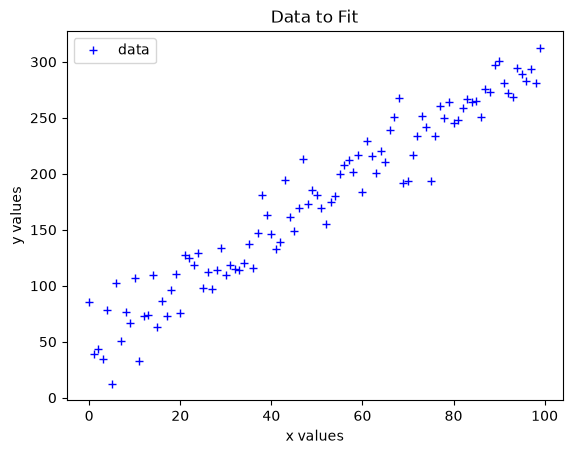

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#load data and put into variables named x,y
x = np.loadtxt('data.txt', usecols=0)
y = np.loadtxt('data.txt', usecols=1)

plt.plot(x,y,'b+',label='data')
plt.legend()
plt.xlabel('x values')
plt.ylabel('y values')
plt.title('Data to Fit')


Let's define a function called linear_fit that implements the equations given above and returns two values: the slope $m$ and the y-intercept. 

In [4]:
def linear_fit(x_data, y_data):
    sum_x = np.sum(x_data)
    sum_x2 = np.sum(x_data**2)
    sum_y = np.sum(y_data)
    sum_xy = np.sum(x_data*y_data)
    n = len(x_data)
    MatA = np.array([[n, sum_x], [sum_x, sum_x2]])
    MatB = np.array([sum_y, sum_xy])
    MatA_inv = np.linalg.inv(MatA)
    constants = np.dot(MatA_inv, MatB)
    slope = constants[1]
    intercept = constants[0]
    return slope, intercept

In [5]:
linear_fit(x,y)

(np.float64(2.57251847659737), np.float64(47.72498329847293))

Great! So now we have the y-intercept and slope of our "best fit" to the data (if you lost the values when you ran the cell, the slope should be ~2.5 and the intercept ~48). From a scientific perspective, we are basically done - it's almost always the values of the slope and intercept that are of interest to us when fitting. But just to see what we've accomplished, let's plot the best fit line over our data:

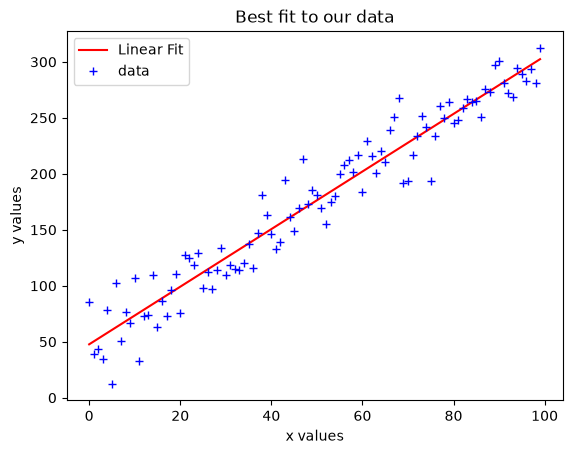

In [ ]:
def plot_fit(x,y):
    slope, intercept = linear_fit(x,y)
    fit_line = slope*x + intercept
    plt.plot(x,fit_line,'r',label='Linear Fit')
    plt.plot(x,y,'b+',label='data')
    plt.legend()
    plt.xlabel('x values')
    plt.ylabel('y values')
    plt.title('Best fit to our data')
    plt.show()
    

plot_fit(x,y)

### Evaluating the Fit
So we have a fit to our data. Is it a good fit? Visually, it seems so. But we can be a little bit more quantitative. 

To do so, we are going to evaluate the **residuals,** that is, the *difference* between the prediction of our fit and our data itself. Given that our data has no uncertainty (at least, none that has been specified), this is easy to calculate. Fill in the residual function below to simply return the difference between the fit and the data, along with a single quantity that is the sum of those residuals. As an arbitrary convention, subtract the fit from the data, instead of the converse.

In [15]:
def return_residuals(x,y):
    slope, intercept = linear_fit(x,y)

    y_diff = intercept + slope*x
    residuals = y_diff - y
    residual_sum = np.sum(residuals)
    return residuals, residual_sum

In [16]:
residuals, sum_residuals = return_residuals(x,y)
print(residuals)
print(sum_residuals)

[-37.52331109  11.07261595   9.33134728  21.22595783 -20.76428835
  48.0309654  -39.70232113  14.75080238  -8.61801727   3.78898674
 -33.27757417  43.22773994   5.59165834   7.00170299 -25.86255493
  22.68040095   2.62697103  18.00732507  -1.88572243 -13.54425578
  23.05878898 -25.5926332  -20.24412885 -11.51121889 -20.08314736
  14.37483976   2.27718158  19.98917889   5.56867197 -11.68069451
  14.90957591   8.58260761  14.95722214  18.45905545  14.75665254
   0.53795178  24.58128302  -4.67865371 -35.53702183 -15.5491544
   4.78855385  19.95978936  16.98409429 -35.88298705  -0.18673201
  14.81112028  -3.0820328  -44.44218476  -1.40157909 -12.11491883
  -5.16278881   9.06724727  26.28858898   9.14919963   6.1739859
 -11.01622374 -16.41992209 -18.3463787   -4.26619002 -17.20398985
  18.44652721 -25.0386286   -8.90944826   8.76226185  -8.23467798
   4.07859045 -22.04515495 -30.39630369 -44.77074661  33.03272866
  34.13854624  13.82070436  -0.52649079 -15.9940335   -3.75792779
  47.0456354

If we take a look at the sum of the residuals, we notice it's an absurdly small value, something like 6e-12. This means that though the spread in residuals might be large, on average, the fit overpredicts the data and underpredicts the data in equal amounts, which is a sign of a good fit.

### Higher Order Polynomial Fits

Alright, so we have successfully fit a straight line (polynomial order 1) to our data. But what if the data were better described by a quadratic? It may look linear when we plot it, but it might be that the "section" of the data we have access to represents a small one, and we can't see the overall curvature well. 

We can fit any order of polynomial to our data (being careful to avoid over-fitting - remember, a high enough order polynomial can fit *any* set of data with 0 residual, but will look pretty wacky). But, instead of going through the pain of constructing a 3x3 array in the way we did above, let's go ahead and utilize the handy function created for the purpose in the Numpy module - since we now know how it works. 

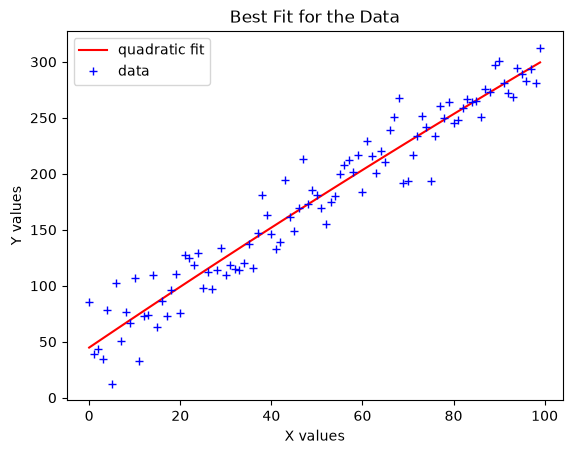

In [12]:
def quadratic_fit(x,y):
    fit_coefficients = np.polyfit(x,y,2)
    a0, a1, a2 = fit_coefficients[0], fit_coefficients[1], fit_coefficients[2]
    return a0, a1, a2
def plot_quadratic_fit(x,y):
    a, b, c = quadratic_fit(x,y)
    fit_line = a*(x**2) + b*x + c
    plt.plot(fit_line, 'r', label='quadratic fit')
    plt.plot(x,y, 'b+', label='data')
    plt.legend()
    plt.xlabel("X values")
    plt.ylabel("Y values")
    plt.title("Best Fit for the Data")

    
plot_quadratic_fit(x,y)

This looks like it could be a decent fit as well, though it doesn't look as good as the linear fit. In fact, if you print them out, you'll see that Polyfit is telling us that it thinks that *if* this data is quadratic, the quadratic coefficient is very small; the remaining linear and constant coefficients are very similar to those in our linear fits. Let's take a look at the residuals:

In [17]:
def quadratic_residuals(x,y):
    a, b, c = quadratic_fit(x,y)
    y_diff = a*(x**2) + b*x + c
    q_residuals = y_diff - y
    q_residual_sum = np.sum(q_residuals)
    return q_residuals, q_residual_sum

q_residuals, q_residual_sum = quadratic_residuals(x,y)
print(q_residual_sum)

1.8829382497642655e-12


Woah. The net sum of the residuals is way larger for the quadratic case. So it would appear that the linear fit is better here, e.g., the data most likely *are* linear in nature. 

Alright, so I'll fess up. The data indeed are linear; I constructed the dataset by taking a perfectly straight line and adding in Gaussian-distributed noise to make it look more like the type of data we might take in a laboratory experiment. 

As a note though, that means situations like this, where one order of fit is demonstrably and majorly better than another, rarely actually happens. Even when *nature* chooses a truly, fundamentally linear relation between two measurable variables, we can almost never obtain measurements of that relation so perfectly distributed around the true values so as to find that the linear (or any other order) fit is the best. In reality, we tend to simply try to use the lowest order fit that adequately describes our data. 

This isn't too difficult - if you, for example, plot the residuals for each data point for both the linear and quadratic fits, you'll find they look similar in form. Typically, if the data truly were quadratic, the linear residuals would have a strong functional form to them (an under, then over, then under fit). (Do it below if you're curious!) 

Fitting data is a **huge** aspect of data analysis, and this tutorial barely scratches the surface. How do we fit if we have differing uncertainties on our data points? What if both the $x$ and $y$ measurements have associated uncertainties? (Hint: this gets very complicated). What if we are fitting in multidimensional parameter spaces? How do we fit curves that are functional in nature, but not polynomials (like Gaussians, exponentials, compositions of other functions, etc.)? All these cases are relevant and important - and will (hopefully) be addressed in further tutorials! 

Congrats! You made it to the end of the tutorial. I hope you enjoyed it, practiced a little python, and learned something about galaxy properties. As always, feel free to contact me (post an issue on the github http://github.com/prappleizer/prappleizer.github.io ) if anything was messed up, confusing, or poorly explained.